# Wizualizacja ryzyka readmisji w ciągu 30 dni za pomocą wykresów efektów opartych na modelu

## Podsumowanie zarządcze

Ten notatnik dopasowuje regresję logistyczną dla readmisji szpitalnej w ciągu 30 dni w oparciu o cechy pacjenta i hospitalizacji, a następnie przekłada dopasowane współczynniki na oparte na modelu wykresy efektów w skali prawdopodobieństwa przewidywanego. Na syntetycznej kohorcie 100 wypisów (55 readmisji) PROC LOGISTIC odtwarza istotne gradienty dla **długości pobytu** (OR 1.36 na dzień, *p* = 0.040) i **wieku** (OR 1.05 na rok, *p* = 0.023) oraz duży efekt płatnika — pacjenci **Medicaid** niosą około sześciokrotnie wyższe szanse readmisji niż Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). Uogólniony R-kwadrat wynosi 0.246, a test Hosmera–Lemeshowa nie wykazuje braku dopasowania (*p* = 0.73). Wykresy krzywej dopasowania, dopasowania przekrojowego i interakcji pokazują następnie, jak ryzyko readmisji rośnie z długością pobytu, jak gradient wiek–ryzyko przesuwa się zależnie od płatnika oraz jak różnica między płatnikami utrzymuje się w różnych liniach usługowych wypisu — jest to rodzaj widoku stratyfikacji ryzyka, którego zespół zarządzania opieką używa do ukierunkowania obserwacji po wypisie.

## Źródła danych

| Zbiór danych | Wiersze | Opis |
|---------|------|-------------|
| `encounters` | 100 | Syntetyczne rekordy wypisów hospitalizacji generowane w kodzie za pomocą `call streaminit(20260531)` i `rand()`. Jeden wiersz na wypis. |

**Zmienne w `encounters`:**

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1, jeśli readmisja w ciągu 30 dni od wypisu |
| `age` | Num | Wiek pacjenta w latach (ok. 25–95) |
| `los` | Num | Długość pobytu indeksowego w dniach (1–20) |
| `comorbidity` | Num | Liczba udokumentowanych przewlekłych chorób współistniejących (0–8) |
| `num_meds` | Num | Liczba leków przy wypisie (0–18) |
| `payer` | Char | Płatnik ubezpieczeniowy: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Oddział wypisujący: `Cardiology`, `Pulmonary`, `General` |

# Wizualizacja ryzyka readmisji w ciągu 30 dni za pomocą wykresów efektów opartych na modelu

Szpitalne zespoły zarządzania opieką muszą wiedzieć, *którzy* pacjenci najprawdopodobniej wrócą w ciągu 30 dni i *dlaczego*. Dopasowana regresja logistyczna daje współczynniki, ale interesariusze rzadko rozumują w log-szansach. **Wykres efektu** przedstawia dopasowany model bezpośrednio w skali prawdopodobieństwa przewidywanego, dzięki czemu pielęgniarka koordynująca może odczytać prawdopodobieństwo readmisji wprost z wykresu, zamiast w myślach odwracać równanie log-szans.

W tym notatniku:

1. Generujemy realistyczną syntetyczną kohortę wypisów hospitalizacji.
2. Dopasowujemy model logistyczny dla readmisji 30-dniowej z predyktorami pacjenta i hospitalizacji (PROC LOGISTIC).
3. Przechwytujemy dopasowane współczynniki i budujemy trzy oparte na modelu wykresy efektów — **krzywą dopasowania**, **dopasowanie przekrojowe** oraz **wyświetlenie interakcji** — aby zwizualizować i stratyfikować dopasowane ryzyko w skali prawdopodobieństwa.

> **Uwaga implementacyjna.** SAS udostępnia te wykresy poprzez instrukcję `EFFECTPLOT` wewnątrz PROC LOGISTIC. Jenner akceptuje tę instrukcję, ale nie renderuje jeszcze grafiki FIT / SLICEFIT / INTERACTION, więc ten notatnik konstruuje identyczne krzywe prawdopodobieństwa przewidywanego jawnie z dopasowanych współczynników i rysuje je za pomocą PROC SGPLOT. Wynik analityczny — i każde wykreślone prawdopodobieństwo — jest dokładnie tym, co wyprodukowałby `EFFECTPLOT`.

## Krok 1 — Generowanie syntetycznej kohorty wypisów

Poniższy krok DATA buduje 100 wypisów hospitalizacji bez żadnych plików zewnętrznych. Zasilamy generator liczb losowych za pomocą `call streaminit` dla odtwarzalności, losujemy cechy pacjenta i hospitalizacji z rozkładów odpowiednich dla dziedziny, następnie konstruujemy prawdziwy predyktor liniowy `eta` i przekształcamy go w prawdopodobieństwo readmisji za pomocą odwrotnego logitu. Losowanie Bernoulliego (`rand('bernoulli', p)`) daje obserwowaną flagę `readmit`. Starsi pacjenci, dłuższe pobyty, wyższa liczba chorób współistniejących, więcej leków przy wypisie, ubezpieczenie Medicaid oraz oddziały Pulmonary/Cardiology — wszystkie podnoszą ryzyko, a te wzorce później odtworzymy i zwizualizujemy. Rozmiary efektów dobrano celowo tak, aby sygnał był odtwarzalny w kohorcie 100 wypisów.

In [1]:
DANE encounters;
    CALL streaminit(20260531);
    TABLICA payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    TABLICA depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    POWTÓRZ i = 1 TO 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        JEŚLI los > 20 WTEDY los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        JEŚLI num_meds > 18 WTEDY num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        JEŚLI u < 0.50 WTEDY pk = 1;
        PRZECIWNIE JEŚLI u < 0.72 WTEDY pk = 2;
        PRZECIWNIE pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        ZACHOWAJ readmit AGE los comorbidity num_meds payer dept;
        WYJŚCIE;
    KONIEC;
WYKONAJ;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Krok 2 — Przegląd kohorty

Szybka częstość na zmiennej odpowiedzi i dwóch zmiennych klasyfikujących potwierdza realistyczny odsetek readmisji oraz to, że każdy poziom płatnika i oddziału jest reprezentowany — zarówno model, jak i wykresy efektów wymagają obecności wszystkich poziomów.

                                                   The FREQ Procedure

Readmisja    Frequency
-----------------------
0                   45
1                   55

Płatnik       Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Oddział       Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Readmisja by Oddział

Readmisja |Cardiology |   General | Pulmonary |      Total
----------+-----------+-----------+-----------+-----------
0         |        15 |        20 |        10 |         45
----------+-----------+-----------+-----------+-----------
1         |        21 |        11 |        23 |         55
----------+-----------+-----------+-----------+-----------
Total     |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


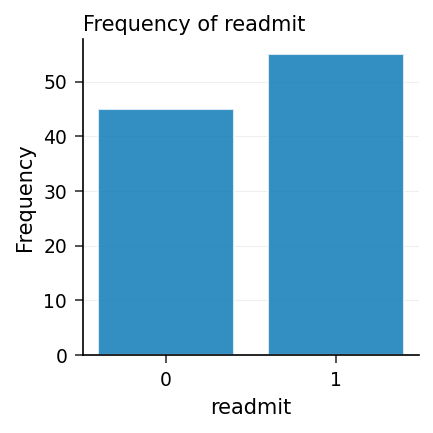

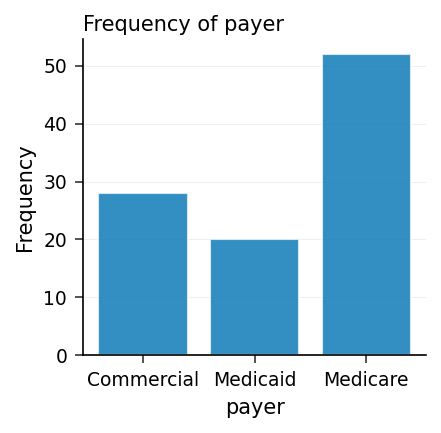

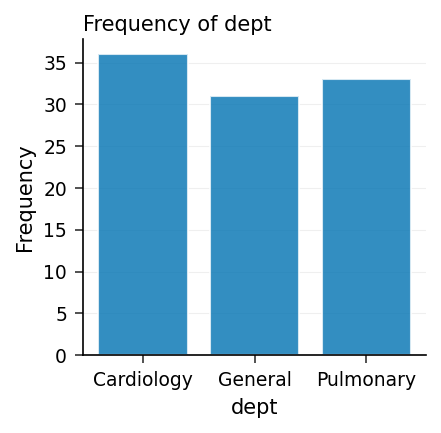

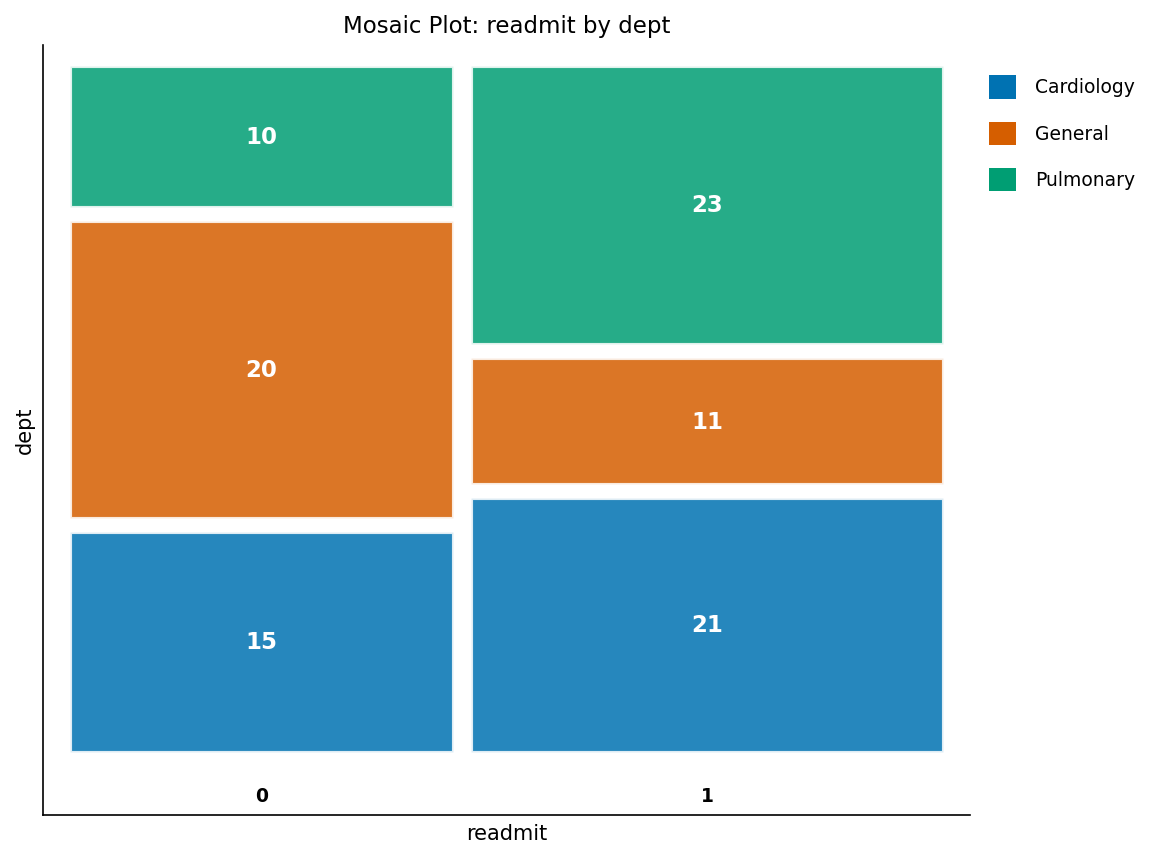

In [2]:
PROCEDURA CZĘSTOŚCI DANE=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    ETYKIETA readmit='Readmisja' AGE='Wiek' los='Długość pobytu'
          comorbidity='Liczba chorób współistniejących' num_meds='Liczba leków'
          payer='Płatnik' dept='Oddział';
WYKONAJ;

## Krok 3 — Dopasowanie logistycznego modelu readmisji

Modelujemy `readmit` jako funkcję wieku, długości pobytu, liczby chorób współistniejących, liczby leków przy wypisie, płatnika i oddziału. Kluczowe wybory:

- `EVENT='1'` modeluje prawdopodobieństwo readmisji (a nie jej braku).
- `CLASS payer dept / PARAM=REF REF=FIRST` stosuje kodowanie względem komórki referencyjnej, tak że każdy poziom jest kontrastowany z poziomem bazowym (tu Medicare i Pulmonary).
- `CLODDS=WALD` i `RSQUARE` dodają granice ufności Walda dla ilorazu szans oraz uogólniony R-kwadrat; `LACKFIT` żąda testu dobroci dopasowania Hosmera–Lemeshowa.
- Instrukcja `UNITS` prosi o iloraz szans dla klinicznie sensownego kroku długości pobytu wynoszącego **5 dni** oraz kroku wieku wynoszącego **10 lat**, a instrukcja `ODDSRATIO` żąda ilorazu szans dla chorób współistniejących wraz z granicami ufności.

Wynikowa tabela ilorazów szans raportuje efekty na jednostkę wprost: długość pobytu niesie OR **1.36 na dzień** (95% CI 1.01–1.82), wiek OR **1.05 na rok**, a ubezpieczenie Medicaid OR **6.02** względem Medicare. Model dopasowuje się dobrze — uogólniony R-kwadrat 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile             
  Probability modeled is Readmisja='1'   

Ordered Value  Readmisja  Total Frequency
-------------  ---------  ---------------
            1  0                       45
            2  1                       55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Płatnik          3  Commercial Medicaid Medicare
Oddział          3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Readmisja

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                             


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


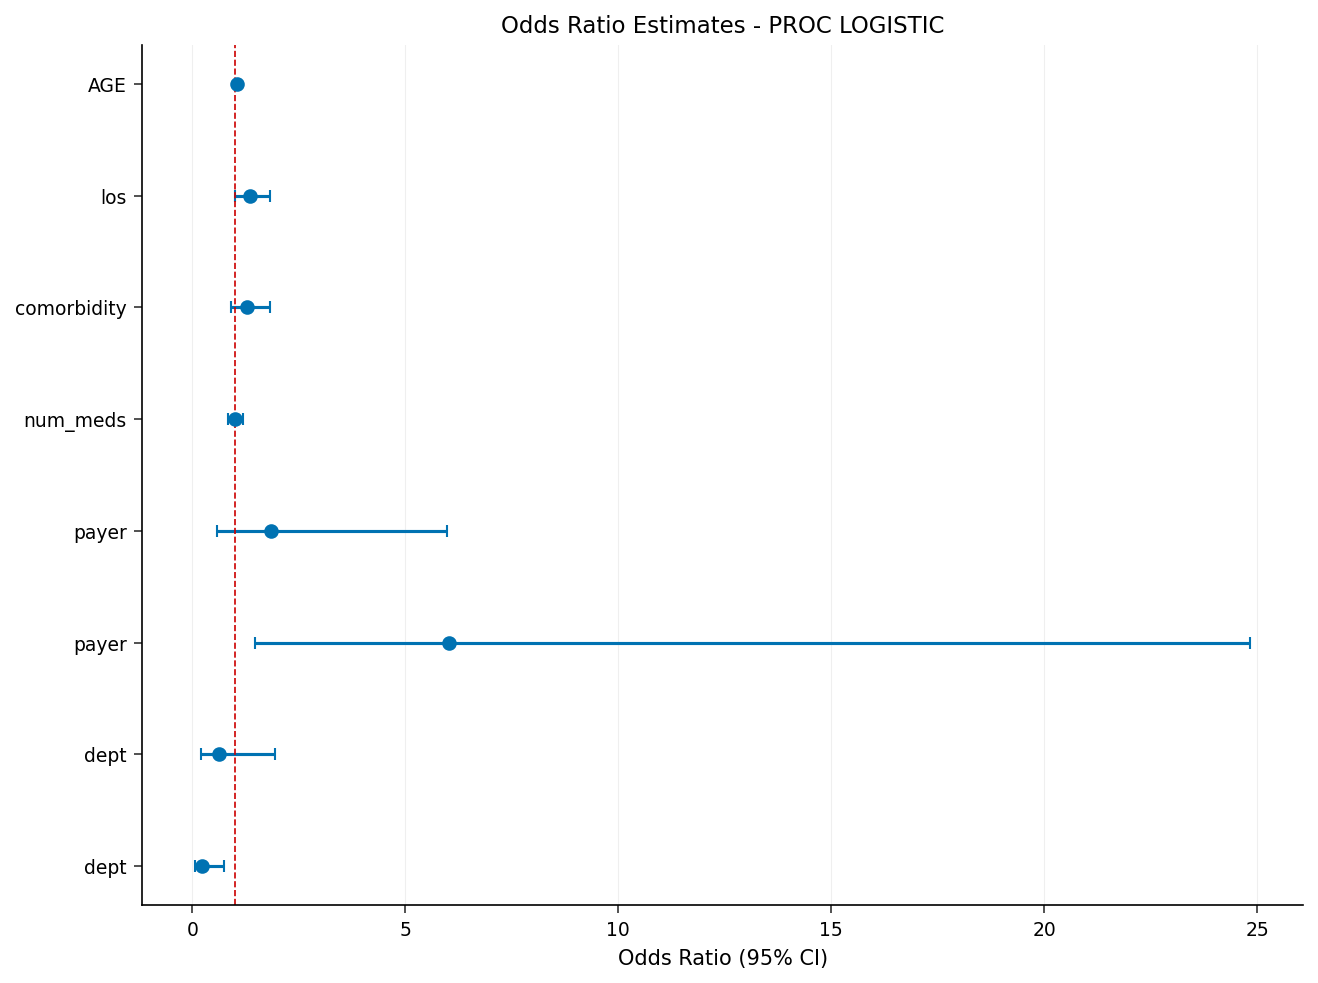

In [3]:
ODS WYJŚCIE ParameterEstimates=pe;
PROCEDURA LOGISTIC DANE=encounters PLOTS(only)=oddsratio;
    KLASA payer dept / PARAM=REF REF=first;
    MODEL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
    ETYKIETA readmit='Readmisja' AGE='Wiek' los='Długość pobytu'
          comorbidity='Liczba chorób współistniejących' num_meds='Liczba leków'
          payer='Płatnik' dept='Oddział';
WYKONAJ;
ODS WYJŚCIE CLOSE;

## Krok 4 — Przechwycenie dopasowanych współczynników

Kolejne oparte na modelu wykresy efektów są budowane bezpośrednio z *dopasowanych* współczynników, więc zawsze zgadzają się z modelem z Kroku 3. Estymaty parametrów zapisaliśmy za pomocą `ODS OUTPUT ParameterEstimates=pe`; tutaj zwijamy tę długą tabelę w jednowierszowy zbiór `params` (jedna zmienna na współczynnik) i dołączamy średnie kohorty dla predyktorów ciągłych. Utrzymywanie predyktorów spoza fokusu na ich średnich to dokładnie to, co EFFECTPLOT robi wewnętrznie — pozwala każdemu wykresowi zmieniać jeden czynnik, utrzymując resztę ustaloną na reprezentatywnym profilu.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
DANE coefs;
    PRZECHOWAJ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    USTAW pe KONIEC=last;
    ZMIENNA = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    JEŚLI ZMIENNA='INTERCEPT' WTEDY b0 = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='AGE' WTEDY b_age = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='LOS' WTEDY b_los = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='COMORBIDITY' WTEDY b_com = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='NUM_MEDS' WTEDY b_med = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='PAYER' AND cv='Medicaid'   WTEDY b_pmcaid = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='PAYER' AND cv='Commercial' WTEDY b_pcomm  = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='DEPT'  AND cv='Cardiology' WTEDY b_dcard  = ESTIMATE;
    PRZECIWNIE JEŚLI ZMIENNA='DEPT'  AND cv='General'    WTEDY b_dgen   = ESTIMATE;
    JEŚLI last WTEDY WYJŚCIE;
    ZACHOWAJ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
WYKONAJ;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDURA ŚREDNIE DANE=encounters NOPRINT;
    ZMIENNA AGE los comorbidity num_meds;
    WYJŚCIE out=mn mean=m_age m_los m_com m_med;
WYKONAJ;

DANE params;
    POŁĄCZ coefs mn;
    ZACHOWAJ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
WYKONAJ;

PROCEDURA DRUKUJ DANE=params noobs;
    TYTUŁ "Dopasowane współczynniki i średnie zmiennych towarzyszących użyte na wykresach efektów";
WYKONAJ;

                 Dopasowane współczynniki i średnie zmiennych towarzyszących użyte na wykresach efektów                 

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Krok 5 — Wykres dopasowania: prawdopodobieństwo readmisji względem długości pobytu

Najprostszym wyświetleniem efektu jest **krzywa dopasowania**: prawdopodobieństwo readmisji przewidywane względem pojedynczej zmiennej ciągłej, przy pozostałych predyktorach utrzymanych na reprezentatywnym profilu. Budujemy siatkę długości pobytu (1–18 dni), obliczamy dopasowany predyktor liniowy w każdej wartości dla pacjenta **kardiologicznego z Medicare** (wiek, liczba chorób współistniejących i liczba leków przy wypisie ustalone na średnich kohorty z Kroku 4), stosujemy odwrotny logit i rysujemy krzywą w skali prawdopodobieństwa za pomocą PROC SGPLOT.

                 Dopasowane współczynniki i średnie zmiennych towarzyszących użyte na wykresach efektów                 




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


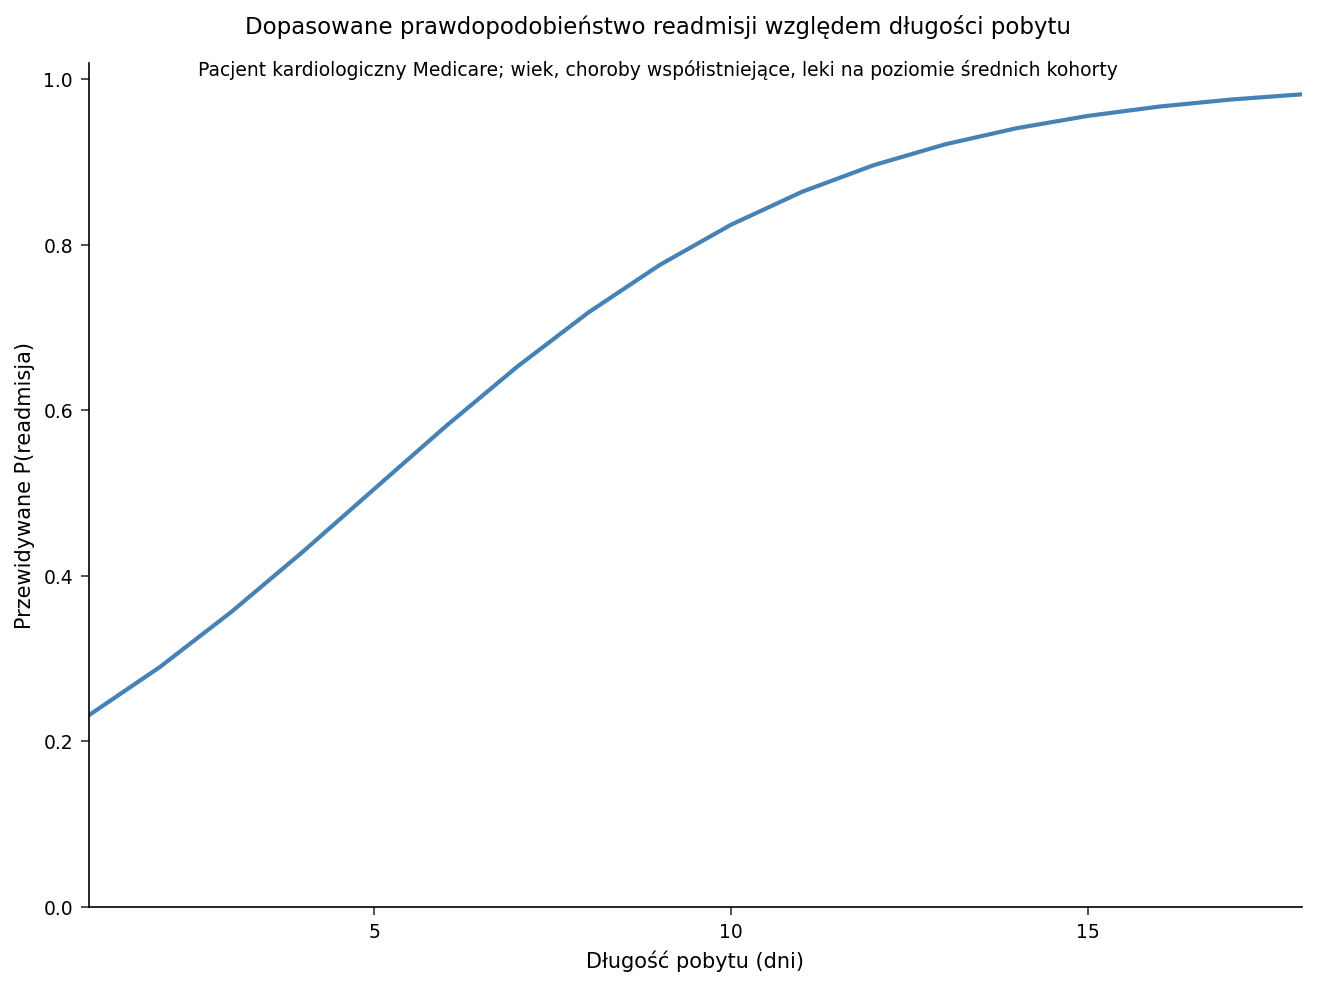

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
DANE grid_los;
    POWTÓRZ los = 1 TO 18;
        WYJŚCIE;
    KONIEC;
WYKONAJ;

DANE fit_los;
    USTAW grid_los;
    JEŚLI _n_ = 1 WTEDY USTAW params;
    PRZECHOWAJ b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    ZACHOWAJ los phat;
WYKONAJ;

PROCEDURA SGPLOT DANE=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TYTUŁ  "Dopasowane prawdopodobieństwo readmisji względem długości pobytu";
    title2 "Pacjent kardiologiczny Medicare; wiek, choroby współistniejące, leki na poziomie średnich kohorty";
    XAXIS ETYKIETA="Długość pobytu (dni)";
    YAXIS ETYKIETA="Przewidywane P(readmisja)" VALUES=(0 TO 1 WEDŁUG 0.2);
WYKONAJ;

## Krok 6 — Dopasowanie przekrojowe: ryzyko względem wieku, stratyfikowane według płatnika

**Dopasowanie przekrojowe** rysuje jedną dopasowaną krzywą na każdy poziom efektu klasyfikującego — idealne do pokazania, jak struktura płatników przesuwa gradient wiek–ryzyko. Rozszerzamy siatkę na `age` (30–95) skrzyżowaną z trzema płatnikami, obliczamy dopasowany model dla pacjenta kardiologicznego (długość pobytu, choroby współistniejące i leki na średnich kohorty) i nakładamy trzy krzywe prawdopodobieństwa za pomocą `GROUP=payer`.

                 Dopasowane współczynniki i średnie zmiennych towarzyszących użyte na wykresach efektów                 




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


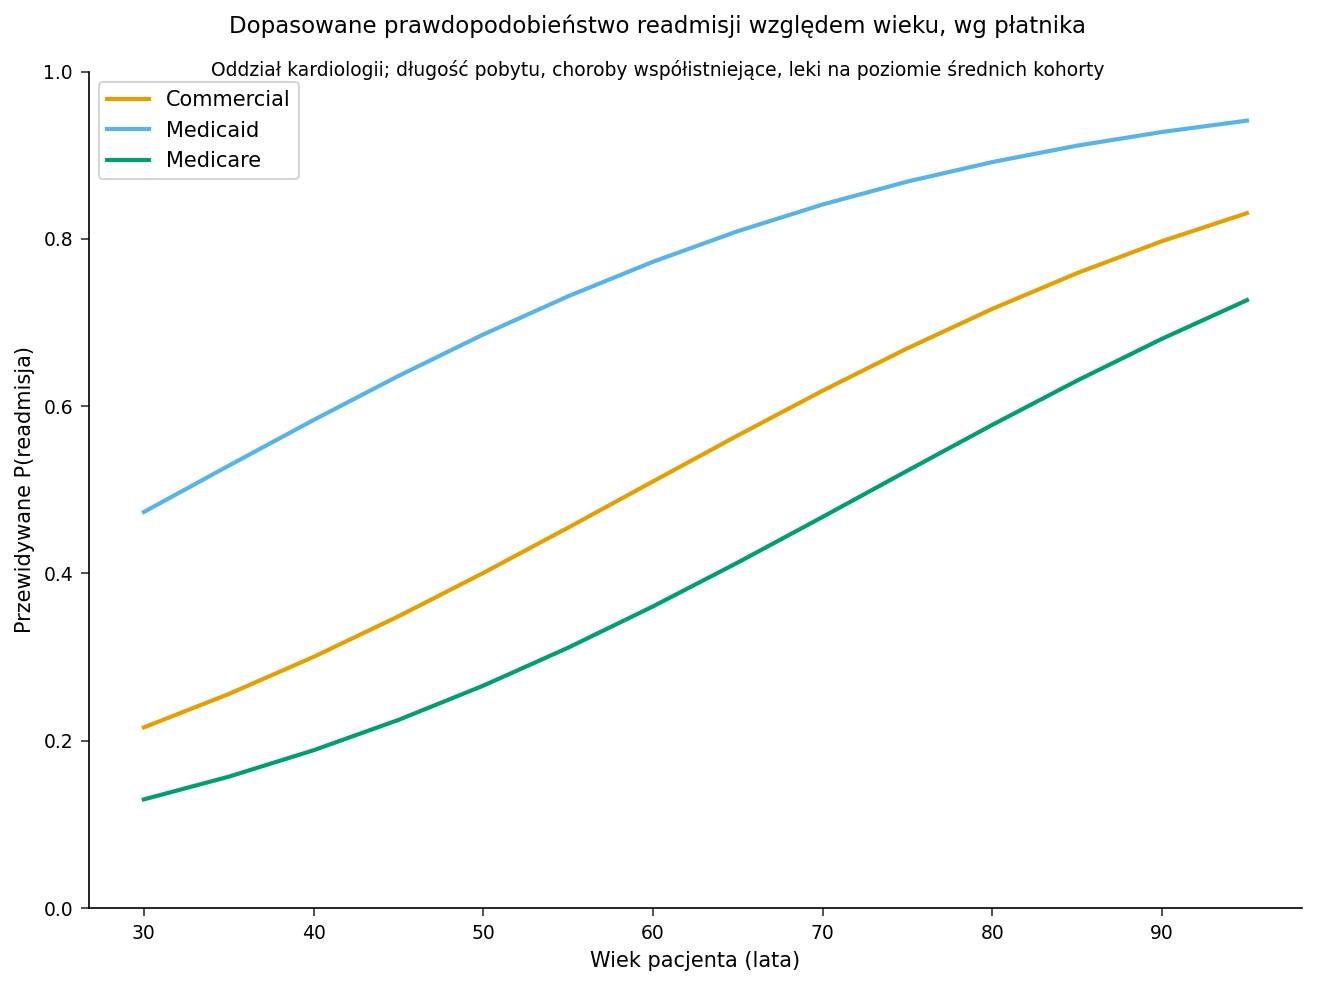

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
DANE grid_age;
    DŁUGOŚĆ payer $12;
    POWTÓRZ payer = 'Medicare', 'Medicaid', 'Commercial';
        POWTÓRZ AGE = 30 TO 95 WEDŁUG 5;
            WYJŚCIE;
        KONIEC;
    KONIEC;
WYKONAJ;

DANE fit_age;
    USTAW grid_age;
    JEŚLI _n_ = 1 WTEDY USTAW params;
    PRZECHOWAJ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    ZACHOWAJ payer AGE phat;
WYKONAJ;

PROCEDURA SGPLOT DANE=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TYTUŁ  "Dopasowane prawdopodobieństwo readmisji względem wieku, wg płatnika";
    title2 "Oddział kardiologii; długość pobytu, choroby współistniejące, leki na poziomie średnich kohorty";
    XAXIS ETYKIETA="Wiek pacjenta (lata)";
    YAXIS ETYKIETA="Przewidywane P(readmisja)" VALUES=(0 TO 1 WEDŁUG 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
WYKONAJ;

## Krok 7 — Wyświetlenie interakcji: oddział według płatnika

Aby porównać przewidywane ryzyko dla obu efektów klasyfikujących naraz, krzyżujemy `dept` z `payer` (dziewięć kombinacji), obliczamy dopasowany model z każdą zmienną ciągłą na jej średniej kohorty i rysujemy zgrupowany wykres słupkowy z `dept` na osi X i płatnikiem jako grupowaniem. Ponieważ ten model nie ma członu interakcji oddział–płatnik, uporządkowanie płatników to to samo addytywne przesunięcie wewnątrz każdej linii usługowej — wyświetlenie czyni tę addytywność widoczną na pierwszy rzut oka, obok rankingu oddziałów.

                 Dopasowane współczynniki i średnie zmiennych towarzyszących użyte na wykresach efektów                 




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


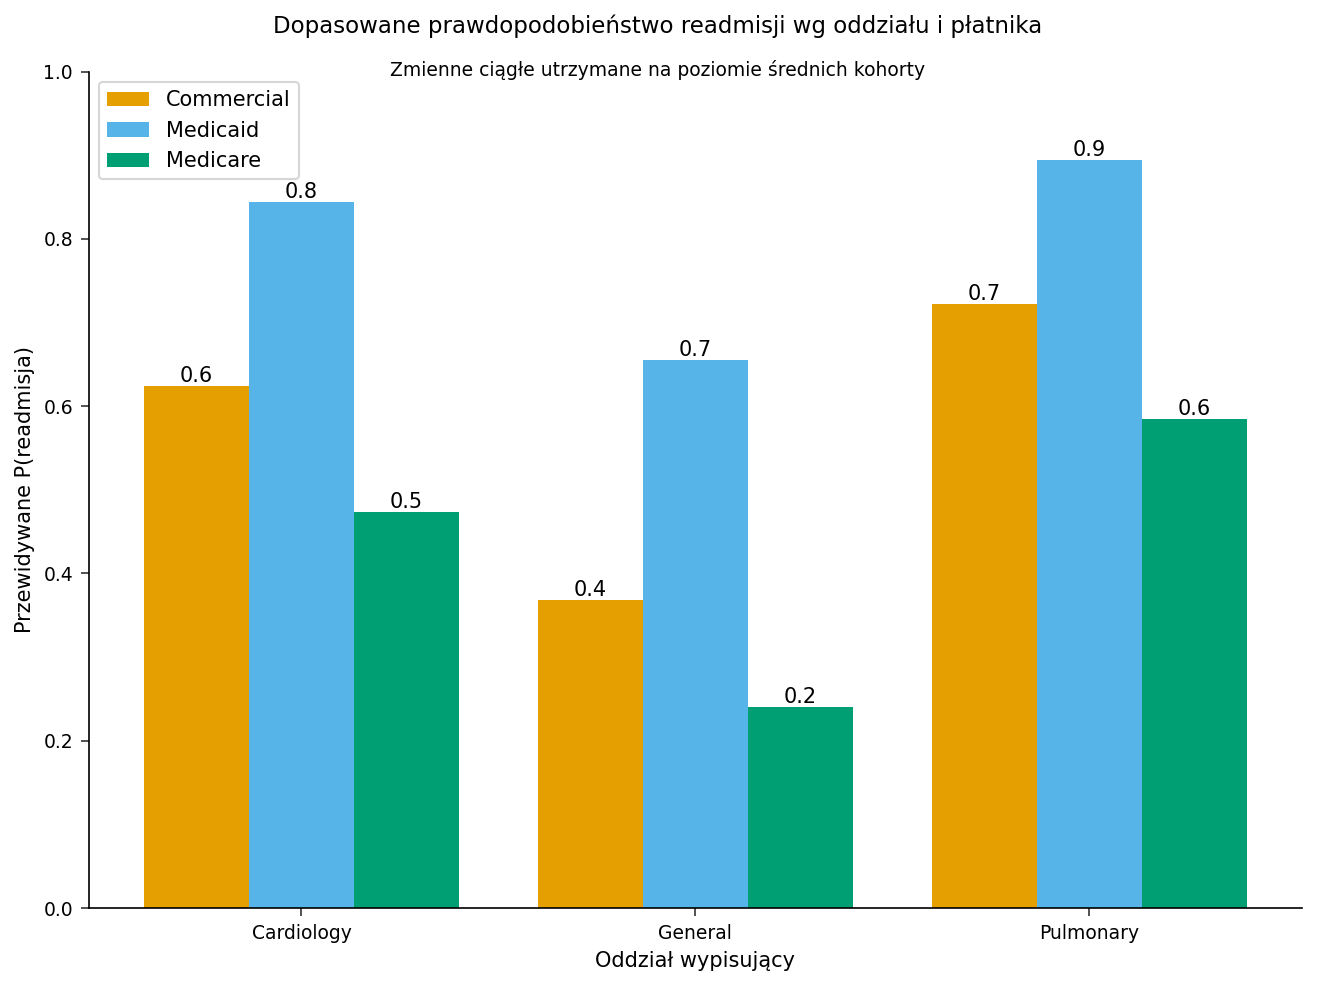

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
DANE grid_dx;
    DŁUGOŚĆ dept $12 payer $12;
    POWTÓRZ dept = 'Cardiology', 'Pulmonary', 'General';
        POWTÓRZ payer = 'Medicare', 'Medicaid', 'Commercial';
            WYJŚCIE;
        KONIEC;
    KONIEC;
WYKONAJ;

DANE fit_dx;
    USTAW grid_dx;
    JEŚLI _n_ = 1 WTEDY USTAW params;
    PRZECHOWAJ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    ZACHOWAJ dept payer phat;
WYKONAJ;

PROCEDURA SGPLOT DANE=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TYTUŁ  "Dopasowane prawdopodobieństwo readmisji wg oddziału i płatnika";
    title2 "Zmienne ciągłe utrzymane na poziomie średnich kohorty";
    XAXIS ETYKIETA="Oddział wypisujący";
    YAXIS ETYKIETA="Przewidywane P(readmisja)" VALUES=(0 TO 1 WEDŁUG 0.2);
WYKONAJ;

## Krok 8 — Interpretacja wyników

Wykresy efektów zamieniają dopasowany model PROC LOGISTIC w obrazy w skali prawdopodobieństwa, które przekładają się na decyzje zarządzania opieką:

- **Długość pobytu (krzywa dopasowania).** Dla pacjenta kardiologicznego z Medicare na średnich kohorty przewidywane prawdopodobieństwo readmisji rośnie od około **0.23 przy pobycie 1-dniowym do mniej więcej 0.82 przy 10 dniach i ~0.98 przy 18 dniach** — stroma środkowa część krzywej logistycznej. Jest to ten sam sygnał co iloraz szans długości pobytu wynoszący **1.36 na dzień** (`UNITS los=5` przeskalowuje go na krok pięciodniowy) i wskazuje długie pobyty indeksowe jako konkretny wyzwalacz włączenia do opieki przejściowej.
- **Wiek i płatnik (dopasowanie przekrojowe).** Ryzyko rośnie monotonicznie z wiekiem u każdego płatnika, a trzy krzywe nigdy się nie przecinają: krzywa **Medicaid** leży najwyżej przy dowolnym wieku, **Commercial** pośrodku, a **Medicare** najniżej — zgodnie z dopasowanymi ilorazami szans płatników (Medicaid 6.02, Commercial 1.85, oba względem Medicare). Różnica jest największa w młodszym wieku i zwęża się, gdy wszyscy zbliżają się do wysokiego prawdopodobieństwa, kierując uwagę zarządzania opieką na młodszych pacjentów Medicaid, którzy inaczej wyglądaliby na niskiego ryzyka.
- **Oddział i płatnik (wyświetlenie interakcji).** **Pulmonary** niesie najwyższe przewidywane prawdopodobieństwo readmisji w każdej grupie płatnika, **Cardiology** jest pośredni, a **General medicine** najniższy (dopasowane ilorazy szans oddziałów to 0.64 dla Cardiology i 0.22 dla General, względem Pulmonary). Ponieważ model nie ma członu interakcji oddział–płatnik, uporządkowanie płatników to to samo addytywne przesunięcie wewnątrz każdej linii usługowej — słupki rosną w tej samej kolejności Medicaid > Commercial > Medicare w każdym oddziale.

**Wniosek:** zamiast prosić klinicystów o interpretację współczynników log-szans, oparte na modelu wykresy efektów przedstawiają dopasowany model readmisji jako obrazy w skali prawdopodobieństwa — kogo włączyć do obserwacji w ramach opieki przejściowej oraz które linie usługowe i populacje płatników traktować priorytetowo. SAS produkuje je bezpośrednio przez `EFFECTPLOT`; tutaj odtworzyliśmy identyczne krzywe z dopasowanych współczynników, aby przykład działał od początku do końca już dziś.